In [7]:
import collections
import math
import torch
from torch import nn
import os
import hashlib
import zipfile
from torch.utils import data
from matplotlib_inline import backend_inline
import matplotlib.pyplot as plt
import time
from IPython import display

In [8]:
class Encoder(nn.Module):
    """编码器解码器架构的基本编码器接口"""
    def __init__(self,**kwargs):
        super(Encoder,self).__init__(**kwargs)
    
    def forward(self,X,*args):
        raise NotImplementedError

class Decoder(nn.Module):
    """编码器解码器架构的基本解码器接口"""
    def __init__(self,**kwargs):
        super(Decoder,self).__init__(**kwargs)
    def init_state(self,enc_outputs,*args):
        raise NotImplementedError
    def forward(self,X,state):
        raise NotImplementedError

class EncoderDecoder(nn.Module):
    """编码器-解码器架构的基类"""
    def __init__(self,encoder,decoder,**kwargs):
        super(EncoderDecoder,self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
    def forward(self,enc_X,dec_X,*args):
        enc_outputs = self.encoder(enc_X,*args)
        dec_state = self.decoder.init_state(enc_outputs,*args)
        return self.decoder(dec_X,dec_state)

In [9]:
class Seq2SeqEncoder(Encoder):
    """用于序列到序列学习的循环神经网络编码器"""
    def __init__(self,vocab_size,embed_size,num_hiddens,num_layers,dropout=0,**kwargs):
        super(Seq2SeqEncoder,self).__init__(**kwargs)
        # 嵌入层
        self.embedding = nn.Embedding(vocab_size,embed_size)
        self.rnn = nn.GRU(embed_size,num_hiddens,num_layers,dropout=dropout)

    def forward(self,X,*args):
        # 输出‘X’的形状为（batch_size,num_steps,embed_size）
        X = self.embedding(X)
        # 在循环神经网络模型中，第一个轴对应于时间步
        X = X.permute(1,0,2)
        # 如果未提及状态，则默认为0
        output,state = self.rnn(X)
        # output的形状为（num_steps,batch_size,num_hiddens）
        # state[0]的形状为（num_layers,batch_size,num_hiddens）
        return output,state

In [10]:
encoder = Seq2SeqEncoder(vocab_size=10,embed_size=8,num_hiddens=16,num_layers=2)
encoder.eval()
X = torch.zeros((4,7),dtype=torch.long)
output,state = encoder(X)
output.shape

torch.Size([7, 4, 16])

In [11]:
state.shape

torch.Size([2, 4, 16])

In [12]:
class Seq2SeqDecoder(Decoder):
    """用于序列到序列学习的循环神经网络解码器"""
    def __init__(self,vocab_size,embed_size,num_hiddens,num_layers,dropout=0,**kwargs):
        super(Seq2SeqDecoder,self).__init__(**kwargs)
        self.embedding = nn.Embedding(vocab_size,embed_size)
        self.rnn = nn.GRU(embed_size+num_hiddens,num_hiddens,num_layers,dropout=dropout)
        self.dense = nn.Linear(num_hiddens,vocab_size)
    def init_state(self,enc_outputs,*args):
        return enc_outputs[1]
    def forward(self,X,state):
        # 输出‘X’的形状为（batch_size,num_steps,embed_size）
        X = self.embedding(X).permute(1,0,2)
        # 广播context,使其具有与X相同的num_steps
        context = state[-1].repeat(X.shape[0],1,1)
        X_and_context = torch.cat((X,context),2)
        output,state = self.rnn(X_and_context,state)
        output = self.dense(output).permute(1,0,2)
        # output的形状为（batch_size,num_steps,vocab_size）
        # state[0]的形状为（num_layers,batch_size,num_hiddens）
        return output,state

In [13]:
decoder = Seq2SeqDecoder(vocab_size=10,embed_size=8,num_hiddens=16,num_layers=2)
decoder.eval()
state = decoder.init_state(encoder(X))
output,state = decoder(X,state)
output.shape,state.shape

(torch.Size([4, 7, 10]), torch.Size([2, 4, 16]))

In [14]:
def sequence_mask(X,valid_len,value=0):
    """在序列中屏蔽不相关的项"""
    maxlen = X.size(1)
    mask = torch.arange((maxlen),dtype=torch.float32,device=X.device)[None,:]<valid_len[:,None]
    X[~mask] = value
    return X

X = torch.tensor([[1,2,3],[4,5,6]])
sequence_mask(X,torch.tensor([1,2]))

tensor([[1, 0, 0],
        [4, 5, 0]])

In [15]:
X = torch.ones(2,3,4)
sequence_mask(X,torch.tensor([1,2]),value=-1)

tensor([[[ 1.,  1.,  1.,  1.],
         [-1., -1., -1., -1.],
         [-1., -1., -1., -1.]],

        [[ 1.,  1.,  1.,  1.],
         [ 1.,  1.,  1.,  1.],
         [-1., -1., -1., -1.]]])

In [16]:
class MaskedSoftmaxCELoss(nn.CrossEntropyLoss):
    """带屏蔽的softmax交叉熵损失函数"""
    # pred的形状为（batch_size,num_steps,vocab_size）
    # label的形状为（batch_size,num_steps）
    # valid_len的形状为（batch_size,）
    def forward(self,pred,label,valid_len):
        weights = torch.ones_like(label)
        weights = sequence_mask(weights,valid_len)
        self.reduction='none'
        unweighted_loss = super(MaskedSoftmaxCELoss,self).forward(pred.permute(0,2,1),label)
        weighted_loss = (unweighted_loss*weights).mean(dim=1)
        return weighted_loss

In [17]:
loss = MaskedSoftmaxCELoss()
loss(torch.ones(3,4,10),torch.ones((3,4),dtype=torch.long),torch.tensor([4,2,0]))

tensor([2.3026, 1.1513, 0.0000])

In [18]:
def grad_clipping(net,theta):
    """截断梯度"""
    if isinstance(net,nn.Module):
        params = [p for p in net.parameters() if p.requires_grad]
    else:
        params = net.params
    norm = torch.sqrt(sum(torch.sum((p.grad**2)) for p in params))
    if norm > theta:
        for param in params:
            param.grad[:] *= theta/norm

In [19]:
def try_gpu(i=0):
    """如果存在，则返回gpu(i)，否则返回cpu()"""
    if torch.cuda.device_count()>=i+1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

In [20]:
# 辅助函数：绘图用
def use_svg_display():
    """使用svg格式在jupyter中显示绘图"""
    backend_inline.set_matplotlib_formats('svg')

def set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
    """设置matplotlib的轴"""
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_xscale(xscale)
    axes.set_yscale(yscale)
    axes.set_xlim(xlim)
    axes.set_ylim(ylim)
    if legend:
        axes.legend(legend)
    axes.grid()
    
class Animator:  #@save
    """在动画中绘制数据"""
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1,
                 figsize=(3.5, 2.5)):
        # 增量地绘制多条线
        if legend is None:
            legend = []
        use_svg_display()
        self.fig, self.axes = plt.subplots(nrows, ncols, figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes, ]
        # 使用lambda函数捕获参数
        self.config_axes = lambda: set_axes(self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
        self.X, self.Y, self.fmts = None, None, fmts

    def add(self, x, y):
        # 向图表中添加多个数据点
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        if not hasattr(x, "__len__"):
            x = [x] * n
        if not self.X:
            self.X = [[] for _ in range(n)]
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        self.axes[0].cla()
        for x, y, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x, y, fmt)
        self.config_axes()
        display.display(self.fig)
        display.clear_output(wait=True)

In [21]:
# 辅助函数：计算时间
class Timer:  #@save
    """记录多次运行时间"""
    def __init__(self):
        self.times = []
        self.start()
    def start(self):
        """启动计时器"""
        self.tik = time.time()
    def stop(self):
        """停止计时器并将时间记录在列表中"""
        self.times.append(time.time() - self.tik)
        return self.times[-1]
    def avg(self):
        """返回平均时间"""
        return sum(self.times) / len(self.times)
    def sum(self):
        """返回时间总和"""
        return sum(self.times)
    def cumsum(self):
        """返回累计时间"""
        return np.array(self.times).cumsum().tolist()

In [22]:
def grad_clipping(net,theta):
    """截断梯度"""
    if isinstance(net,nn.Module):
        params = [p for p in net.parameters() if p.requires_grad]
    else:
        params = net.params
    norm = torch.sqrt(sum(torch.sum((p.grad**2)) for p in params))
    if norm > theta:
        for param in params:
            param.grad[:] *= theta/norm

In [23]:
# 辅助函数：累加器
class Accumulator:
    def __init__(self,n):
        self.data = [0.0]*n
    def add(self,*args):
        self.data = [a+float(b) for a,b in zip(self.data,args)]
    def reset(self):
        self.data = [0.0]*len(self.data)
    def __getitem__(self,idx):
        return self.data[idx]

In [24]:
def train_seq2seq(net,data_iter,lr,num_epochs,tgt_vocab,device):
    """训练序列到序列模型"""
    def xavier_init_weights(m):
        if type(m) == nn.Linear:
            nn.init.xavier_uniform_(m.weight)
        if type(m) == nn.GRU:
            for param in m._flat_weights_names:
                if "weight" in param:
                    nn.init.xavier_uniform_(m._parameters[param])
    net.apply(xavier_init_weights)
    net.to(device)
    optimizer = torch.optim.Adam(net.parameters(),lr=lr)
    loss = MaskedSoftmaxCELoss()
    net.train()
    animator = Animator(xlabel='epoch',ylabel='loss',xlim=[10,num_epochs])
    for epoch in range(num_epochs):
        timer = Timer()
        metric = Accumulator(2)  # 训练损失总和，词元数量
        for batch in data_iter:
            optimizer.zero_grad()
            X,X_valid_len,Y,Y_valid_len = [x.to(device) for x in batch]
            bos = torch.tensor([tgt_vocab['<bos>']]*Y.shape[0],device=device).reshape(-1,1)
            dec_input = torch.cat([bos,Y[:,:-1]],1)
            Y_hat,_ = net(X,dec_input,X_valid_len)
            l = loss(Y_hat,Y,Y_valid_len)
            l.sum().backward()  # 损失函数的标量进行“反向传播”
            grad_clipping(net,1)
            num_tokens = Y_valid_len.sum()
            optimizer.step()
            with torch.no_grad():
                metric.add(l.sum(),num_tokens)
        if (epoch+1)%10 == 0:
            animator.add(epoch+1,(metric[0]/metric[1],))
    print(f'loss{metric[0]/metric[1]:.3f},{metric[1]/timer.stop():.1f}'f'tokens/sec on {str(device)}')

In [25]:
class Vocab:
    """文本词表"""
    def __init__(self,tokens=None,min_freq=0,reserved_tokens=None):
        if tokens is None:
            tokens = []
        if reserved_tokens is None:
            reserved_tokens = []
        # 按出现频率排列
        counter = count_corpus(tokens)
        self._token_freqs = sorted(counter.items(),key = lambda x:x[1],reverse=True)
        # 未知词元的索引为0
        self.idx_to_token = ['<unk>'] + reserved_tokens
        self.token_to_idx = {token:idx for idx,token in enumerate(self.idx_to_token)}
        for token,freq in self.token_freqs:
            if freq < min_freq:
                break
            if token not in self.token_to_idx:
                self.idx_to_token.append(token)
                self.token_to_idx[token] = len(self.idx_to_token) - 1

    def __len__(self):
        return len(self.idx_to_token)
        
    # def __getitem__(self,tokens):
    #     if not isinstance(tokens,(list,tuple)):
    #         return self.token_to_idx.get(tokens,self.unk)
    #     return [self.token_to_idx[token] for token in tokens]
    
    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk)   # 单个 token 使用 get
        return [self.token_to_idx.get(token, self.unk) for token in tokens]   # 列表推导使用 get
    
    def to_tokens(self,indices):
        if not isinstance(indices,(list,tuple)):
            return self.idx_to_token[indices]
        return [self.idx_to_token[index] for index in indices]
    
    @property
    def unk(self):
        return 0
    @property
    def token_freqs(self):
        return self._token_freqs

def count_corpus(tokens):
    """统计词元出现的频率"""
    # 这里的tokens是一维列表或二维列表
    if len(tokens)==0 or isinstance(tokens[0],list):
        # 将词元列表展平成一个列表
        tokens = [token for line in tokens for token in line]
    return collections.Counter(tokens)

In [26]:
# 9.5 机器翻译与数据集的

DATA_HUB = dict()
DATA_URL = 'http://d2l-data.s3-accelerate.amazonaws.com/'
DATA_HUB['fra-eng'] = (DATA_URL + 'fra-eng.zip','94646ad1522d915e7b0f9296181140edcf86a4f5')

def build_array_nmt(lines, vocab, num_steps):
    """将机器翻译的文本序列转换成小批量"""
    lines = [vocab[l] for l in lines]
    lines = [l + [vocab['<eos>']] for l in lines]
    array = torch.tensor([truncate_pad(l, num_steps, vocab['<pad>']) for l in lines])
    valid_len = (array != vocab['<pad>']).type(torch.int32).sum(1)
    return array, valid_len

def load_array(data_arrays, batch_size, is_train=True):
    """构造一个 PyTorch 数据迭代器"""
    dataset = data.TensorDataset(*data_arrays) # 将输入数据封装为 TensorDataset
    return data.DataLoader(dataset, batch_size, shuffle=is_train) # 返回 DataLoader

def truncate_pad(line, num_steps, padding_token):
    """截断或填充文本序列"""
    if len(line) > num_steps:
        return line[:num_steps]  # 截断
    return line + [padding_token] * (num_steps - len(line))  # 填充

def tokenize_nmt(text, num_examples=None):
    """词元化“英语－法语”数据数据集"""
    source, target = [], []
    for i, line in enumerate(text.split('\n')):
        if num_examples and i > num_examples:
            break
        parts = line.split('\t')
        if len(parts) == 2:
            source.append(parts[0].split(' '))
            target.append(parts[1].split(' '))
    return source, target

def download(name,cache_dir=os.path.join('.','data')):
    "下载一个DATA_HUB中的文件返回本地文件名"
    assert name in DATA_HUB,f"{name}不存在于{DATA_HUB}"
    url,sha1_hash = DATA_HUB[name]
    os.makedirs(cache_dir,exist_ok=True)
    fname = os.path.join(cache_dir,url.split('/')[-1])
    if os.path.exists(fname):
        sha1 = hashlib.sha1()
        with open(fname,'rb') as f:
            while True :
                data = f.read(1048576)
                if not data:
                     break
                sha1.update(data)
        if sha1.hexdigest() == sha1_hash:
            return fname
    print(f'正在从{url}下载{fname}...')
    r =  requests.get(url,stream=True,verify=True)
    with open(fname,'wb') as f:
        f.write(r.content)
    return fname
    
def download_extract(name, folder=None):  #@save
    """下载并解压zip/tar文件"""
    fname = download(name)
    base_dir = os.path.dirname(fname)
    data_dir, ext = os.path.splitext(fname)
    if ext == '.zip':
        fp = zipfile.ZipFile(fname, 'r')
    elif ext in ('.tar', '.gz'):
        fp = tarfile.open(fname, 'r')
    else:
        assert False, '只有zip/tar文件可以被解压缩'
    fp.extractall(base_dir)
    return os.path.join(base_dir, folder) if folder else data_dir

def read_data_nmt():
    """载入“英语－法语”数据集"""
    data_dir = download_extract('fra-eng')
    with open(os.path.join(data_dir, 'fra.txt'), 'r',encoding='utf-8') as f:
        return f.read()

def preprocess_nmt(text):
    """预处理“英语－法语”数据集"""
    def no_space(char, prev_char):
        return char in set(',.!?') and prev_char != ' '

    # 使用空格替换不间断空格
    # 使用小写字母替换大写字母
    text = text.replace('\u202f', ' ').replace('\xa0', ' ').lower()
    # 在单词和标点符号之间插入空格
    out = [' ' + char if i > 0 and no_space(char, text[i - 1]) else char
           for i, char in enumerate(text)]
    return ''.join(out)

def load_data_nmt(batch_size, num_steps, num_examples=600):
    """返回翻译数据集的迭代器和词表"""
    text = preprocess_nmt(read_data_nmt())
    source, target = tokenize_nmt(text, num_examples)
    src_vocab = Vocab(source, min_freq=2,reserved_tokens=['<pad>', '<bos>', '<eos>'])
    tgt_vocab = Vocab(target, min_freq=2,reserved_tokens=['<pad>', '<bos>', '<eos>'])
    src_array, src_valid_len = build_array_nmt(source, src_vocab, num_steps)
    tgt_array, tgt_valid_len = build_array_nmt(target, tgt_vocab, num_steps)
    data_arrays = (src_array, src_valid_len, tgt_array, tgt_valid_len)
    data_iter = load_array(data_arrays, batch_size)
    return data_iter, src_vocab, tgt_vocab

loss0.022,5816.7tokens/sec on cuda:0


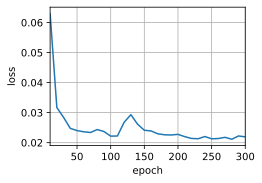

In [27]:
embed_size,num_hiddens,num_layers,dropout = 32,332,2,0.1
batch_size,num_steps = 64,10
lr,num_epochs,device = 0.005,300,try_gpu()

train_iter,src_vocab,tgt_vocab = load_data_nmt(batch_size,num_steps)
encoder = Seq2SeqEncoder(len(src_vocab),embed_size,num_hiddens,num_layers,dropout)
decoder = Seq2SeqDecoder(len(tgt_vocab),embed_size,num_hiddens,num_layers,dropout)
net = EncoderDecoder(encoder,decoder)
train_seq2seq(net,train_iter,lr,num_epochs,tgt_vocab,device)

In [31]:
def predict_seq2seq(net,src_sentence,src_vocab,tgt_vocab,num_steps,device,save_attention_weights=False):
    """序列到序列模型的预测"""
    # 在预测时将net设置为评估模式
    net.eval()
    src_tokens = src_vocab[src_sentence.lower().split(' ')]+[src_vocab['<eos>']]
    enc_valid_len = torch.tensor([len(src_tokens)],device=device)
    src_tokens = truncate_pad(src_tokens,num_steps,src_vocab['<pad>'])
    # 添加批量轴
    enc_X = torch.unsqueeze(torch.tensor(src_tokens,dtype=torch.long,device=device),dim=0)
    enc_outputs = net.encoder(enc_X,enc_valid_len)
    dec_state = net.decoder.init_state(enc_outputs,enc_valid_len)
    # 添加批量轴
    dec_X = torch.unsqueeze(torch.tensor([tgt_vocab['<bos>']],dtype=torch.long,device=device),dim=0)
    output_seq,attention_weight_seq = [],[]
    for _ in range(num_steps):
        Y,dec_state = net.decoder(dec_X,dec_state)
        # 我们使用预测可能性最大的词元，作为解码器在下一个时间步的输入
        dec_X = Y.argmax(dim=2)
        pred = dec_X.squeeze(dim=0).type(torch.int32).item()
        # 保存注意力权重
        if save_attention_weights:
            attention_weight_seq.append(net.decoder.attention_weights)
        # 一旦序列结束词元被预测，输出序列的生成就完成了
        if pred == tgt_vocab['<eos>']:
            break
        output_seq.append(pred)
    return ' '.join(tgt_vocab.to_tokens(output_seq)),attention_weight_seq

In [32]:
def bleu(pred_seq,label_seq,k):
    """计算BLEU"""
    pred_tokens,label_tokens = pred_seq.split(' '),label_seq.split(' ')
    len_pred,len_label = len(pred_tokens),len(label_tokens)
    score = math.exp(min(0,1-len_label/len_pred))
    for n in range(1,k+1):
        num_matches,label_subs = 0,collections.defaultdict(int)
        for i in range(len_label-n+1):
            label_subs[' '.join(label_tokens[i:i+n])]+=1
        for i in range(len_pred-n+1):
            if label_subs[' '.join(pred_tokens[i:i+n])]>0:
                num_matches += 1
                label_subs[' '.join(pred_tokens[i:i+n])]-=1
        score *= math.pow(num_matches/(len_pred-n+1),math.pow(0.5,n))
    return score

In [33]:
engs = ['go .',"i lost .",'he\'s calm .','i\'m home .']
fras = ['va !','j\'ai perdu .','il est calme .','je suis chez moi .']
for eng,fra in zip(engs,fras):
    translation,attention_weight_seq = predict_seq2seq(net,eng,src_vocab,tgt_vocab,num_steps,device)
    print(f'{eng} => {translation},bleu {bleu(translation,fra,k=2):.3f}')

go . => va !,bleu 1.000
i lost . => j'ai perdu .,bleu 1.000
he's calm . => il est riche .,bleu 0.658
i'm home . => je suis chez moi qui <unk> .,bleu 0.711
